IMPORTING LIBERARIES

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025.csv


In [3]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

In [4]:
# First 5 rows
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [5]:
df.shape

(2640, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [7]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [8]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


EDA

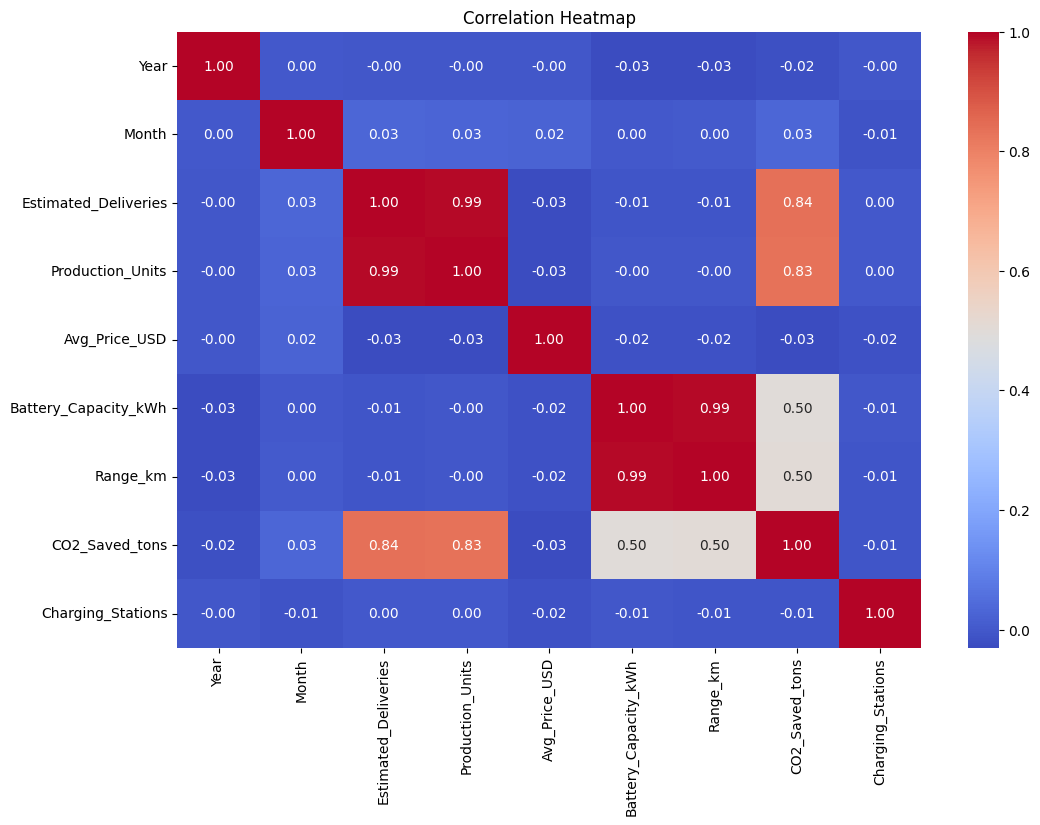

In [9]:
# Correlation matrix
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

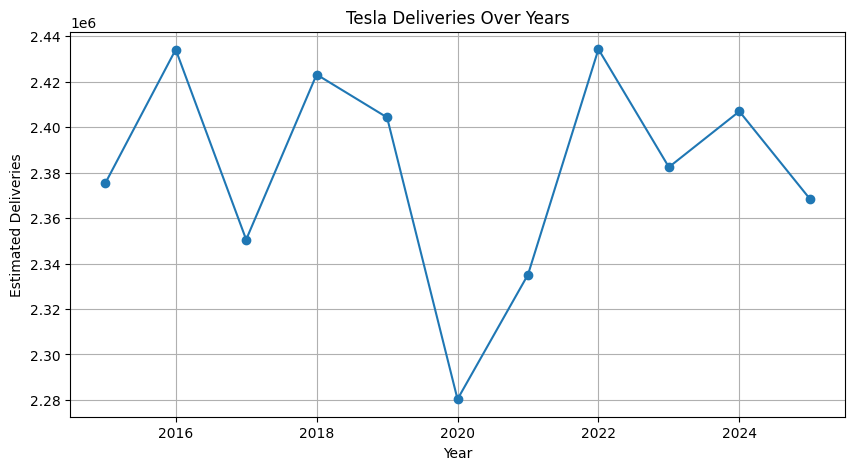

In [11]:
#delivery trend over years
yearly_sales = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10,5))

yearly_sales.plot(marker='o')

plt.title('Tesla Deliveries Over Years')
plt.xlabel('Year')
plt.ylabel('Estimated Deliveries')

plt.grid(True)
plt.show()

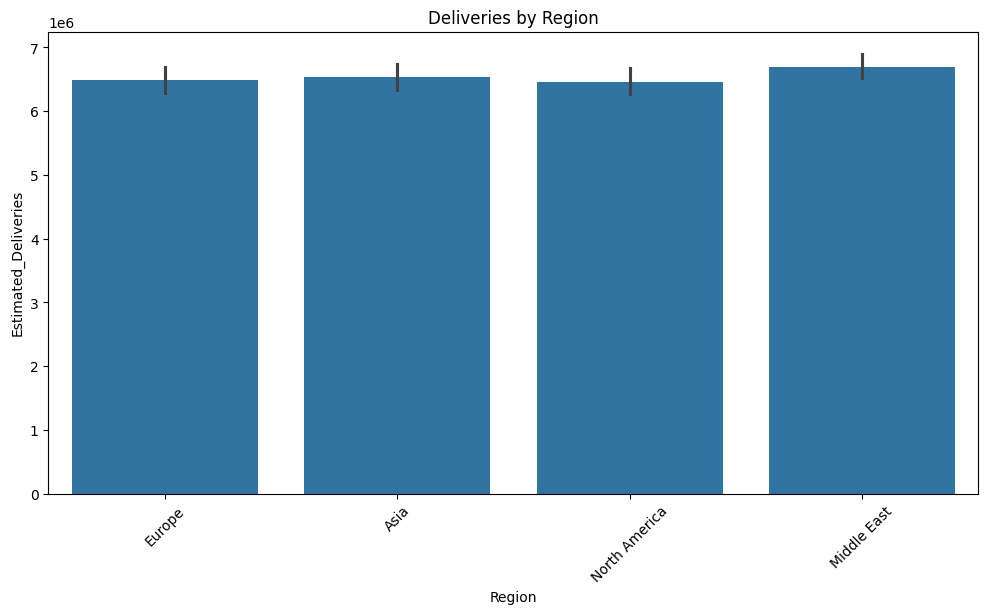

In [12]:
#delivery by region
plt.figure(figsize=(12,6))

sns.barplot(x='Region',
            y='Estimated_Deliveries',
            data=df,
            estimator=sum)

plt.xticks(rotation=45)

plt.title('Deliveries by Region')
plt.show()

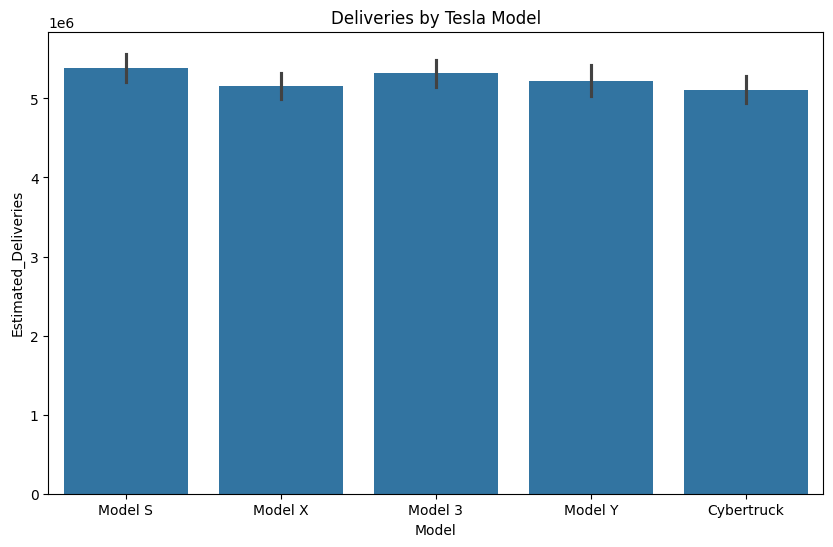

In [14]:
#delivery by tesla model
plt.figure(figsize=(10,6))

sns.barplot(x='Model',
            y='Estimated_Deliveries',
            data=df,
            estimator=sum)

plt.title('Deliveries by Tesla Model')
plt.show()

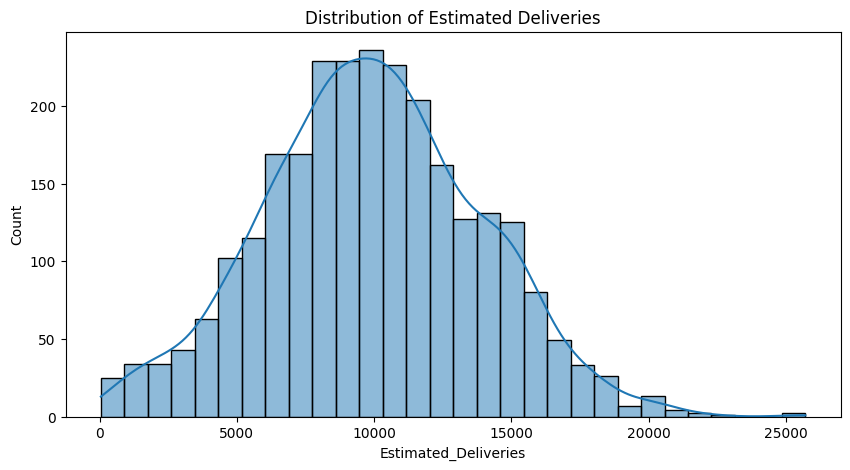

In [15]:
#distribution of estimated delivery
plt.figure(figsize=(10,5))

sns.histplot(df['Estimated_Deliveries'],
             bins=30,
             kde=True)

plt.title('Distribution of Estimated Deliveries')
plt.show()

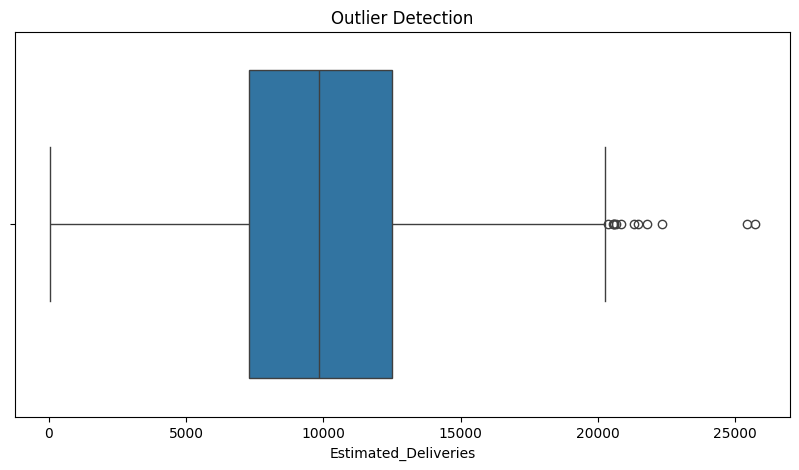

In [16]:
#boxplot for outlier detection
plt.figure(figsize=(10,5))

sns.boxplot(x=df['Estimated_Deliveries'])

plt.title('Outlier Detection')
plt.show()

DATA PREPROCESSING

In [17]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

In [18]:
# Creating LabelEncoder object
le = LabelEncoder()

# Encoding categorical columns
df['Region'] = le.fit_transform(df['Region'])
df['Model'] = le.fit_transform(df['Model'])
df['Source_Type'] = le.fit_transform(df['Source_Type'])

In [19]:
# Features
X = df.drop('Estimated_Deliveries', axis=1)

# Target
y = df['Estimated_Deliveries']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
# Create model
lr = LinearRegression()

# Train model
lr.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)

# Evaluation metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
MAE: 310.1300215468204
RMSE: 383.5765698703892
R2 Score: 0.9901296027802068


In [23]:
# Create model
dt = DecisionTreeRegressor(random_state=42)

# Train model
dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)

Decision Tree Results
MAE: 407.8806818181818
RMSE: 560.5618072726033


In [24]:
# Create model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE: 323.46011363636364
RMSE: 409.4960252956731
R2 Score: 0.9887505867840798


In [25]:
#comparing the models
results = pd.DataFrame({
    'Model': ['Linear Regression',
              'Decision Tree',
              'Random Forest'],

    'MAE': [mae_lr,
            mae_dt,
            mae_rf],

    'RMSE': [rmse_lr,
             rmse_dt,
             rmse_rf],

    'R2 Score': [r2_lr,
                 r2_dt,
                 r2_rf]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,310.130022,383.576570,0.990130
1,Decision Tree,407.880682,560.561807,0.978920
2,Random Forest,323.460114,409.496025,0.988751


Linear Regression achieved the best performance with an R² score of 0.9901, indicating that the dataset exhibits strong linear relationships between the features and estimated deliveries

HYPERPARAMETER TUNING

In [26]:
# Parameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [27]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             scoring='r2')

In [28]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [29]:
best_rf = grid_search.best_estimator_

# Predictions
y_pred_best_rf = best_rf.predict(X_test)

In [30]:
mae_best = mean_absolute_error(y_test, y_pred_best_rf)

rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))

r2_best = r2_score(y_test, y_pred_best_rf)

print("Tuned Random Forest Results")
print("MAE:", mae_best)
print("RMSE:", rmse_best)
print("R2 Score:", r2_best)

Tuned Random Forest Results
MAE: 324.1954992649595
RMSE: 408.43129714185767
R2 Score: 0.9888090097959091


Feature Importance Visualization

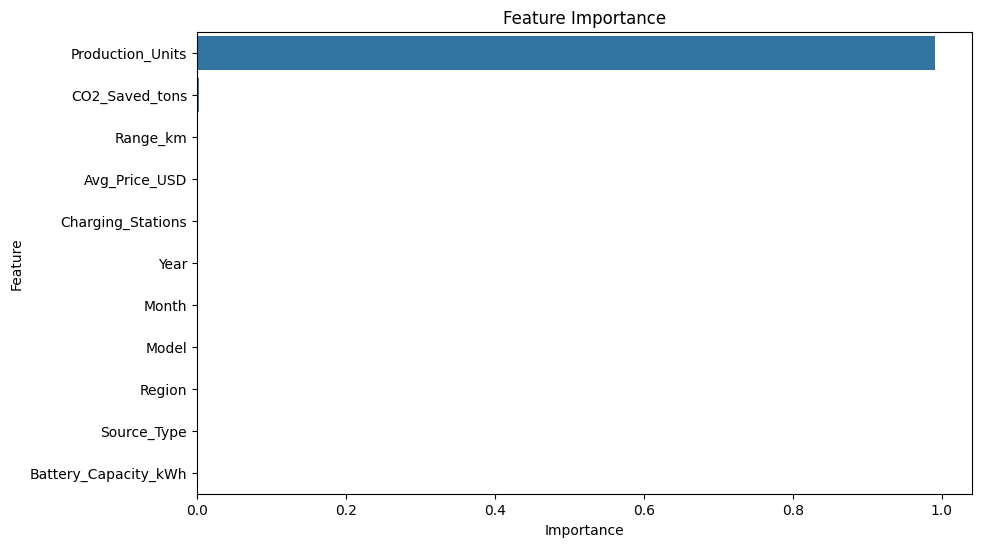

In [31]:
# Feature importance values
importance = rf.feature_importances_

# Feature names
features = X.columns

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

# Sort values
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title('Feature Importance')
plt.show()

Time Series Forecasting using ARIMA

In [32]:
!pip install pmdarima

# Create date column
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + df['Month'].astype(str))

# Group by date
ts_data = df.groupby('Date')['Estimated_Deliveries'].sum()

# Display
ts_data.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 17.0 MB/s eta 0:00:00


,Estimated_Deliveries
Date,
2015-01-01,183180
2015-02-01,165053
2015-03-01,184567
2015-04-01,225623
2015-05-01,184264


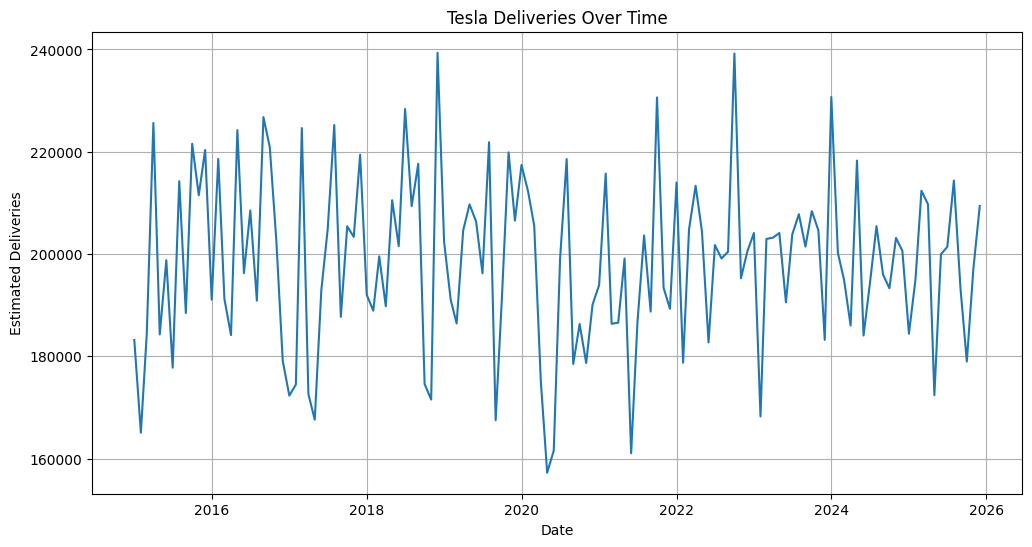

In [33]:
#plotting time series
plt.figure(figsize=(12,6))

plt.plot(ts_data)

plt.title('Tesla Deliveries Over Time')

plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')

plt.grid(True)

plt.show()

In [35]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA model
model = ARIMA(ts_data, order=(1,1,1))

# Train model
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [36]:
# Forecast next 12 months
forecast = model_fit.forecast(steps=12)

print(forecast)

2026-01-01    201130.711312
2026-02-01    199815.368230
2026-03-01    199605.917024
2026-04-01    199572.564655
2026-05-01    199567.253726
2026-06-01    199566.408030
2026-07-01    199566.273364
2026-08-01    199566.251920
2026-09-01    199566.248506
2026-10-01    199566.247962
2026-11-01    199566.247875
2026-12-01    199566.247862
Freq: MS, Name: predicted_mean, dtype: float64


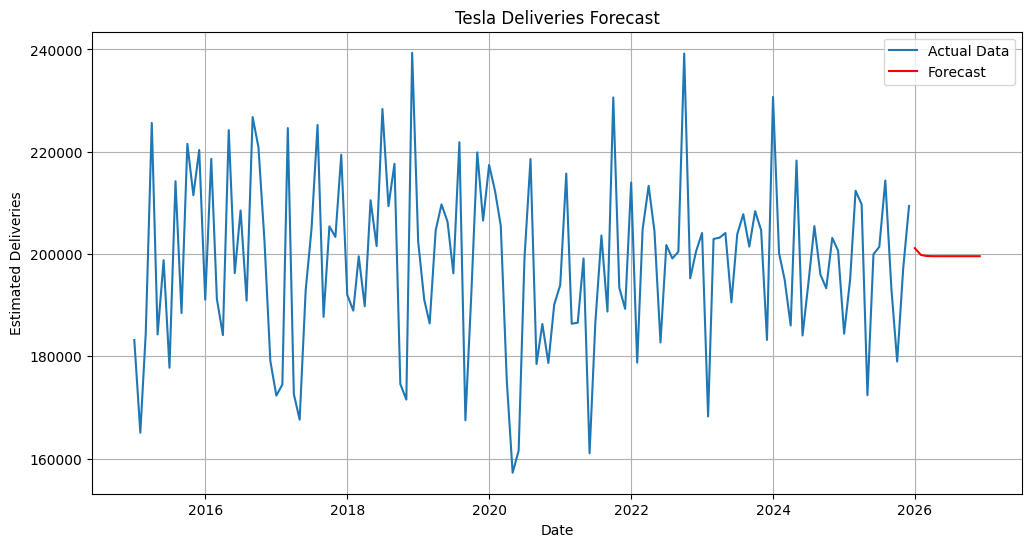

In [37]:
#Plot Forecst
plt.figure(figsize=(12,6))

# Original data
plt.plot(ts_data, label='Actual Data')

# Forecast dates
forecast_index = pd.date_range(
    start=ts_data.index[-1],
    periods=12,
    freq='M'
)

# Forecast plot
plt.plot(
    forecast_index,
    forecast,
    label='Forecast',
    color='red'
)

plt.title('Tesla Deliveries Forecast')

plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')

plt.legend()

plt.grid(True)

plt.show()